# Introduction to DeepInverse

- How to load and display images
- How to use the `deepinv.physics` module to simulate different types of computational imaging modalities
- How to use the `deepinv.optim` module to compute the solution of a variational optimization problem
- How to use the `Trainer` to train `ArtifactRemoval` networks


**Advanced functionalities** not covered now
- Using denoising priors and diffusion models with the `deepinv.sampling` module
- Distributed inference and training (multi-gpus and multi-nodes) with `deepinv.distributed`
- Self-supervised learning and equivariant imaging with the `deepinv.transforms` module


The libary in dense with functionalities so do not hesitate to look directly at the documentation (https://deepinv.github.io/deepinv/index.html) if you need more information on the function you are trying to use.

In [1]:
%%capture
pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv

In [7]:
import deepinv as dinv
import torch
import torchvision

import math
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading and displaying images

You can use `deepinv.utils.load_example` to load examples images from the [DeepInverse huggingface](https://huggingface.co/datasets/deepinv/images/tree/main), e.g. "butterfly.png", "mbappe.jpg", "CT100_256x256_0.pt", "brainweb_t1_ICBM_1mm_subject_0_slice_0.npy"

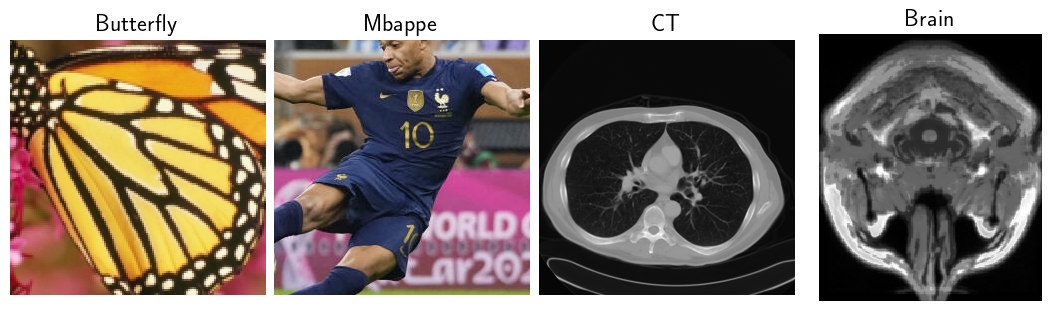

In [8]:
# load the different images in the description
butterfly = dinv.utils.load_example("butterfly.png", img_size=(128,128), resize_mode="resize")
mbappe = dinv.utils.load_example("mbappe.jpg", img_size=(256,256))
ct = dinv.utils.load_example("CT100_256x256_0.pt")
brain = dinv.utils.load_example("brainweb_t1_ICBM_1mm_subject_0_slice_0.npy")[None,None]

# display the images using the dinv.utils.plot function
dinv.utils.plot(
    [butterfly, mbappe, ct, brain],
    titles=["Butterfly", "Mbappe", "CT", "Brain"],
    figsize=(12,3)
)

`deepinverse` also provides utilities to quickly visualize 3D volumes, e.g we can load the "brainweb_t1_ICBM_1mm_subject_0.npy" volume and visualize it with `deepinv.utils.plot_ortho3D`

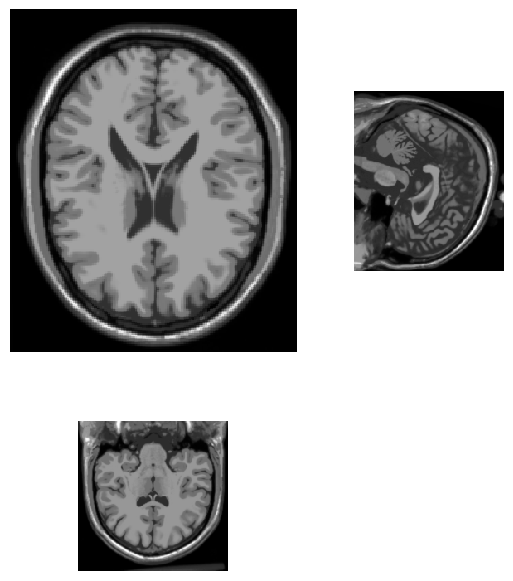

In [9]:
brain_3d = dinv.utils.load_example("brainweb_t1_ICBM_1mm_subject_0.npy")[None,None]
dinv.utils.plot_ortho3D(brain_3d, figsize=(6,6))

## Datasets

`deepinverse` also provide access to a set of [predefined datasets](https://deepinv.org/user_guide/training/datasets.html#predefined-datasets)

In [10]:
# load the knee partition of the SimpleFastMRISliceDataset
knee_dataset = dinv.datasets.Si

# display the first image


AttributeError: module 'deepinv.datasets' has no attribute 'Si'

For distributable datasets, you can use the `download=True` argument to download the dataset to your local machine. The datasets return the images in their original format (PIL, numpy, etc..). You can use `torchvision.transforms` to pre-process the images and convert them to torch tensors.

In [5]:
from torchvision.transforms import Compose, RandomCrop, ToTensor

In [6]:
# load the CBSD68 dataset with appropriate pre-processing


# display the first 8 images of the CBSD68 dataset using dinv.utils.plot


# Forward models with `deepinverse`

In `deepinverse` we describe a general forward measurement process as follows:

\begin{equation}
  y = N (A(x))
\end{equation}

where $x \in \mathbb{R}^n$ is the ground-truth signal, $y \in \mathbb{R}^m$ are the measurements, $A: \mathbb{R}^n \to \mathbb{R}^m$ is a deterministic mapping and $N: \mathbb{R}^m \to \mathbb{R}^m$ is a stochastic degradation process.

The library supports a wide range of computational imaging modalities (e.g. denoising, deblurring, super-resolution, inpainting, compressed sensing, MRI, CT, etc..). The forward models are implemented in the `deepinv.physics` module, every physics inherits from the base `deepinv.physics.Physics` class (which inherits itself from `torch.nn.Module`).

The `forward` method of the physics class implements the "complete" forward model $y = N(A(x))$ and the `A` method implements the deterministic mapping $A(x)$.

DeepInverse supports a large variety of noise models: `GaussianNoise`, `PoissonNoise`, `GammaNoise`, etc. They are all accessible in the `deepinv.physics.noise` module.

### Denoising


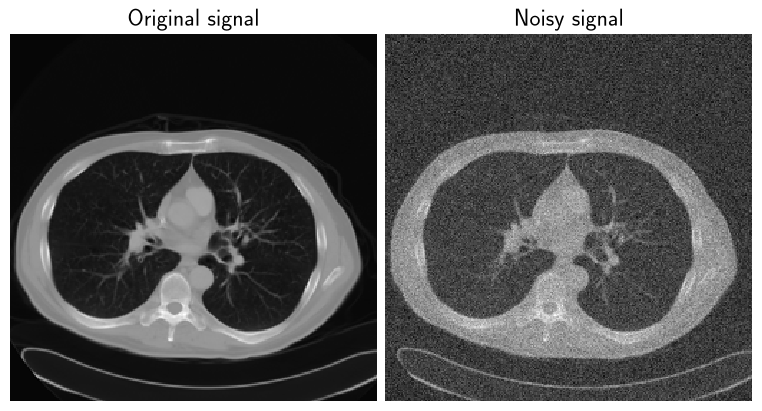

In [ ]:
# define a standard denoising physics with Gaussian noise


# apply the physics to the CT image to get a noisy version

# display the results


## Linear inverse problems

### Creating a physics

/tmp/ipykernel_7541/2516706578.py:2: DeprecationWarning: Function 'gaussian_blur' is deprecated since 0.4.1. Use 'deepinv.physics.functional.blur.gaussian_blur' instead.
  filter = dinv.physics.blur.gaussian_blur(sigma=3., device=device)


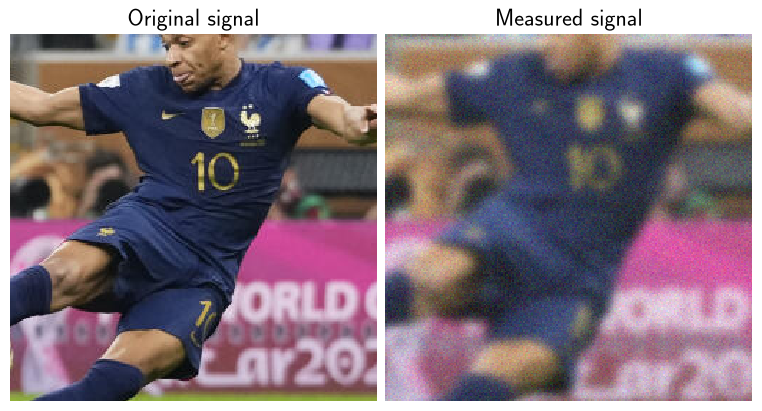

In [ ]:
# instantiate a Gaussian blur filter

# create an instance of Blur with Gaussian noise model

# blur mbappe and display results


### Updating a physics

Updating the parameters of a physics and its noise models is done via the `update` method of the `physics`. The method takes keyword arguments corresponding to the parameters of the physics and its noise models.

Levin09.npy degradation downloaded in /home/rvo/.cache/deepinv


/home/rvo/projects/deepinv/deepinv/physics/forward.py:245: UserWarning: The provided tensor for parameter 'filter' is on a different device (cpu) than the current parameter device (cuda:0). The current device will be used.
  self.update_parameters(**kwargs)


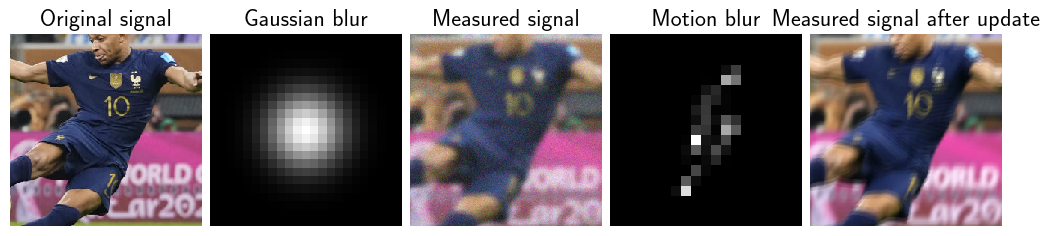

In [ ]:
# load degradation kernel from HF "Levin09.npy" (2D motion blur kernel)

# update the physics parameters with motion kernel and new sigma value (e.g. 1/255.)

# compute new measurements

# display measurements and associated filters

### Physics generator

[Generators](https://deepinv.org/api/deepinv.physics.html#generators) allow to generate random parameterization for specific physics, e.g. for `Blur` and `BlurFFT` physics, `deepinv` supports the generation of random blur kernels for multiple type of acquisitions: motion blur, gaussian blur, diffraction blur, etc. Every generator is defined in the `deepinv.physics.generators` module.

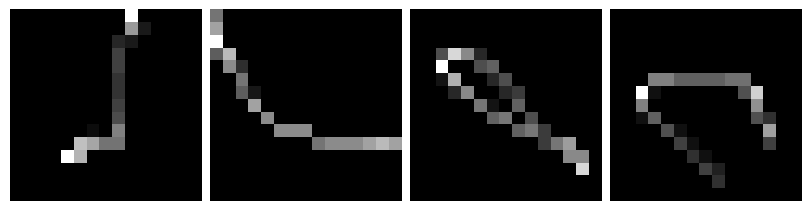

In [ ]:
# define a global rng to control randomness

# define a sigma_generator


# define a motionblur_generator


# sample a batch of random parameters and display them


Generators of different type can be summed to create a global generator and update the physics in a single step

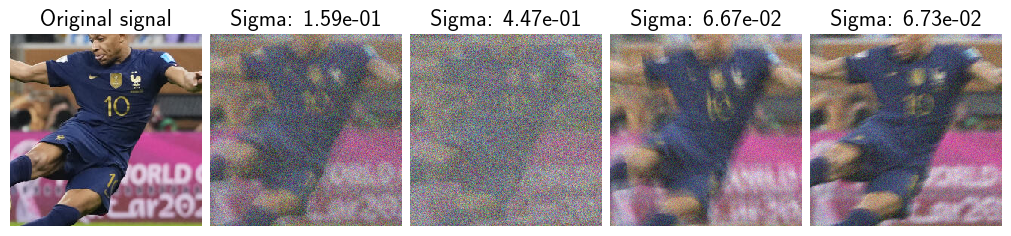

In [ ]:
# sum the sigma_generator and motionblur_generator

# draw params with batch_size

# update params

# compute different version of measurements

# display the results

Two generators of the same type can also be composed so that at time t, one can sample from two different distribution of parameters seamlessly

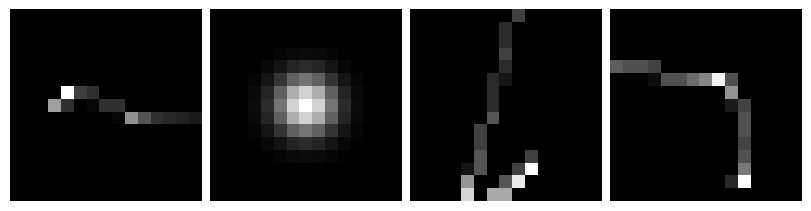

In [ ]:
# define gaussianblur_generator


# create a global_generator using GeneratorMixture


# draw params and plot sampled filters


### Basic reconstruction

Instanciating a `LinearPhysics` gives you automatically access to a number of methods to perform basic reconstruction: `A_adjoint`, `A_dagger`, `prox_l2` are defined for all physics

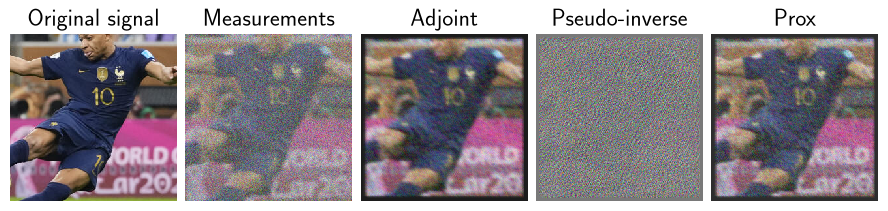

In [ ]:
# draw params from global_generator and update the params of the physics

# simulate measurements y

# compute adjoint, pseudo-inverse and prox

# display reconstructions


## Optimization algorithms

The [`deepinv.optim`](https://deepinv.org/user_guide/reconstruction/optimization.html#optim) module provides a number of already implemented algorithms to solve problems of the form

$$
\begin{equation}
  \underset{x}{\arg\min} \quad f(x,y) + \lambda g(x)
\end{equation}, \quad \lambda > 0
$$

where $f: \mathcal{X} \times \mathcal{Y} \to \mathbb{R}^+$ represents a data-fidelity term and $g: \mathcal{X} \to \mathbb{R}^+$ is a regularization term.

Defining a working optimization algorithms requires creating a number of objects first:
- a `DataFidelity` object from `deepinv.optim.data_fidelity`
- a `Prior` from `deepinv.optim.prior`
- an optimization algorithm

In [ ]:
# define an L2 data fidelity term, a TV prior and a PGD optimizer



In [ ]:
physics.update(sigma=20/255.)
y = physics(mbappe)

# run the pgd algorithm and use x_adj as init, pass the ground_truth x_gt and compute_metrics


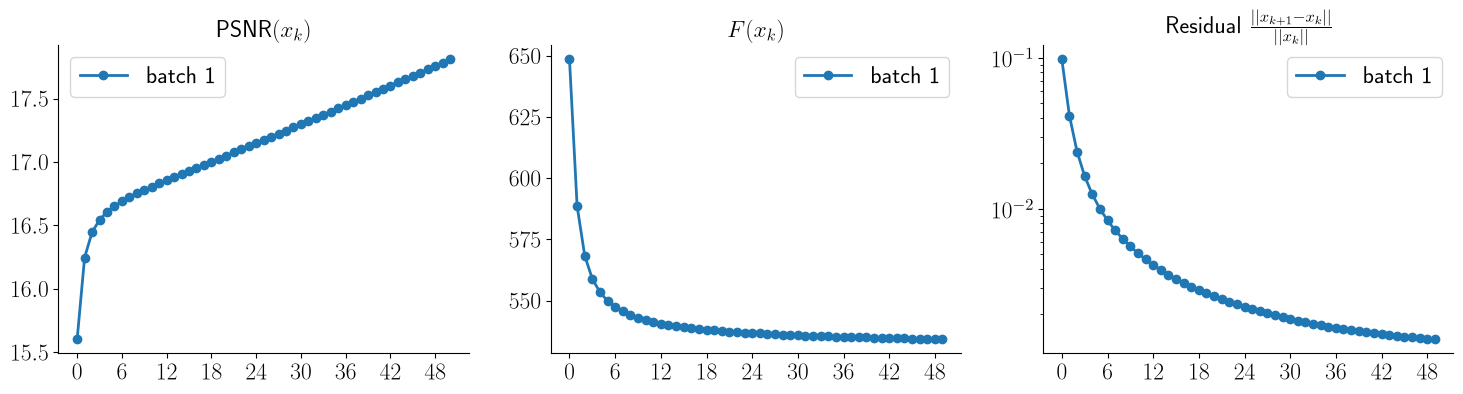

In [ ]:
# use plot_curves to display metrics during optimization


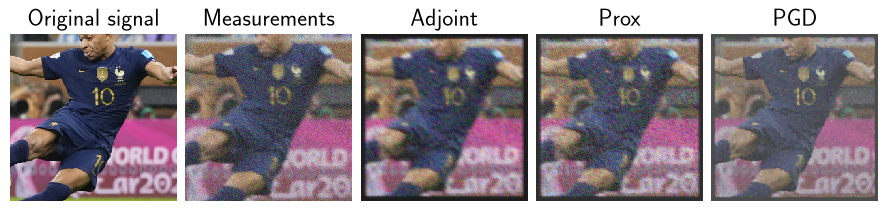

In [ ]:
# display results


## Pretrained reconstruction networks

Deep neural networks in `deepinverse` can inherit from two classes:
- [`Denoiser`](https://deepinv.org/api/stubs/deepinv.models.Denoiser.html#deepinv.models.Denoiser), the network takes as input a noisy signal `x` and a standard deviation scalar `sigma`
- [`ArtifactRemoval`](https://deepinv.org/api/stubs/deepinv.models.ArtifactRemoval.html), the network takes as input measurement `y` and the associated `physics`

DeepInverse provide a number standard networks in the litterature (benchmark on CBSD https://deepinv.org/auto_benchmarks/cbsd68_gaussian_denoising.html)

Downloading: "https://huggingface.co/deepinv/drunet/resolve/main/drunet_deepinv_color_finetune_22k.pth?download=true" to /root/.cache/torch/hub/checkpoints/drunet_deepinv_color_finetune_22k.pth


100%|██████████| 125M/125M [00:01<00:00, 70.3MB/s]


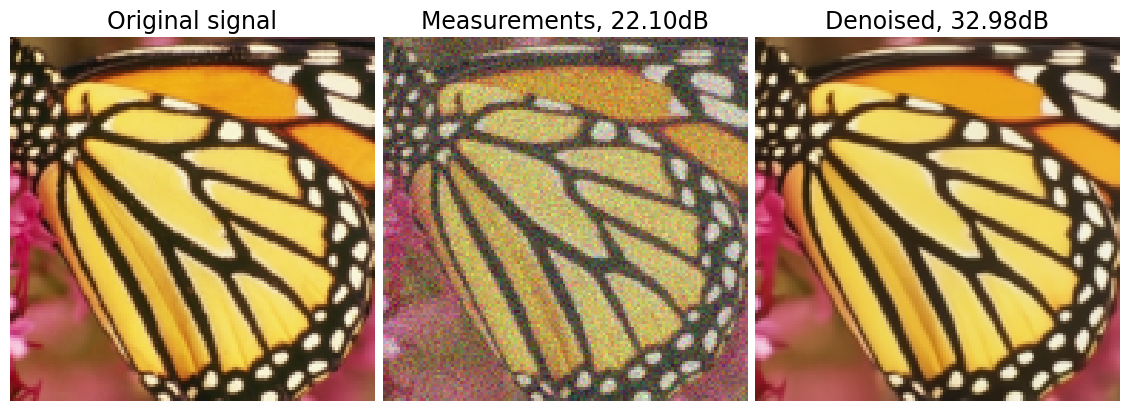

In [ ]:
# show example of pretrained denoising with drunet

# create a denoising physcs

# apply denoising physics to the butterfly image

# denoise the measurements with the pretrained drunet and display results with PSNR values


Downloading: "https://huggingface.co/mterris/ram/resolve/main/ram.pth.tar" to /root/.cache/torch/hub/checkpoints/ram.pth.tar


100%|██████████| 136M/136M [00:11<00:00, 12.7MB/s]


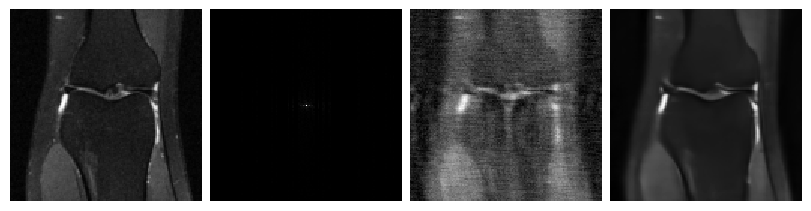

In [ ]:
# load a knee image from the knee_dataset


# instantiate a single-coil MRI physics with a Gaussian mask generator


# simulate measurements and adjoint


# create a pretrained RAM model and apply it to the measurements


## Trainer

DeepInverse provides a `Trainer` class to train `Reconstructor` networks.

In [ ]:
# Load the CBSD68 dataset and create a train/val split with appropriate pre-processing


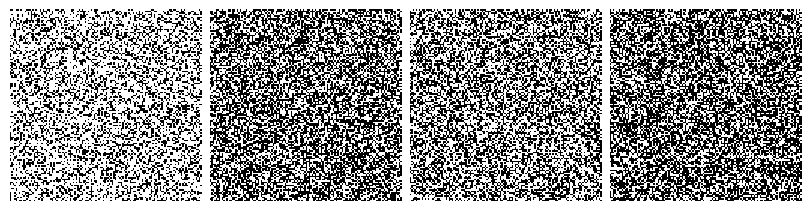

In [ ]:
# create an Inpainting physics with a Bernoulli splitting mask generator


# draw a batch of masks and display them


In [ ]:
# create an ArtifactRemoval model with a DRUNet backbone


# define training parameters and optimizer


The model has 32640960 trainable parameters


/home/rvo/projects/deepinv/deepinv/training/trainer.py:1330: UserWarning: non_blocking_transfers=True but DataLoader.pin_memory=False; set pin_memory=True to overlap host-device copies with compute.
  self.setup_train()
Train epoch 1/5:   0%|          | 0/15 [00:00<?, ?it/s]

Train epoch 1/5:  93%|█████████▎| 14/15 [00:03<00:00,  4.60it/s, TotalLoss=0.00215, PSNR=29.3]

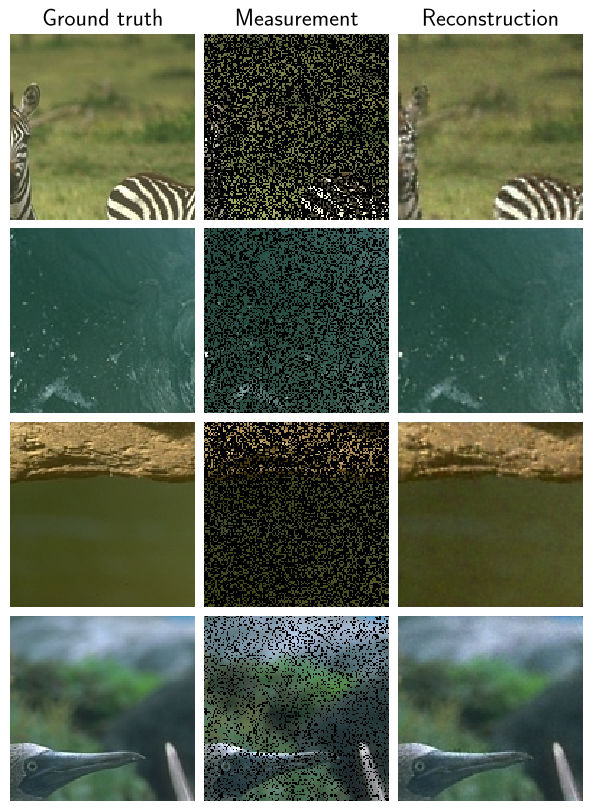

Eval epoch 1/5:  33%|███▎      | 1/3 [00:00<00:00,  9.13it/s, PSNR=25.7]

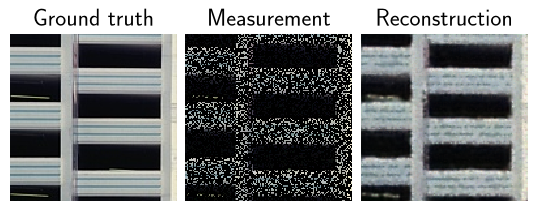

Eval epoch 1/5: 100%|██████████| 3/3 [00:00<00:00,  8.06it/s, PSNR=25.7]

Best model saved at epoch 1



Train epoch 2/5:  93%|█████████▎| 14/15 [00:03<00:00,  4.41it/s, TotalLoss=0.0016, PSNR=29.8] 

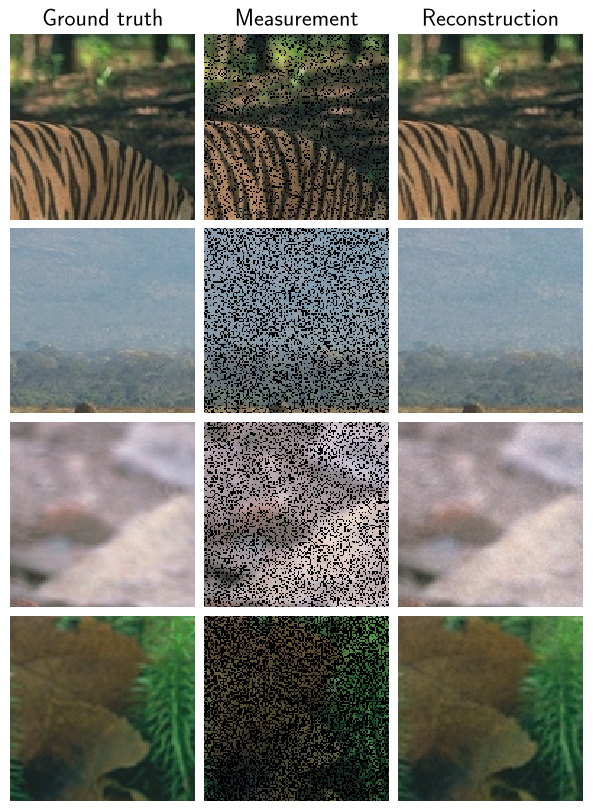

Eval epoch 2/5:  67%|██████▋   | 2/3 [00:00<00:00, 16.09it/s, PSNR=25]  

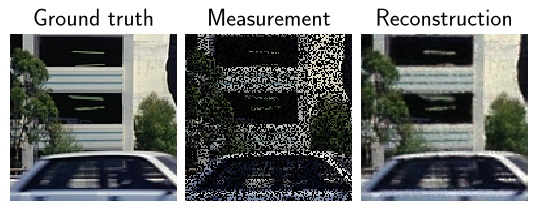

Train epoch 3/5:  93%|█████████▎| 14/15 [00:03<00:00,  4.59it/s, TotalLoss=0.00189, PSNR=29.3]

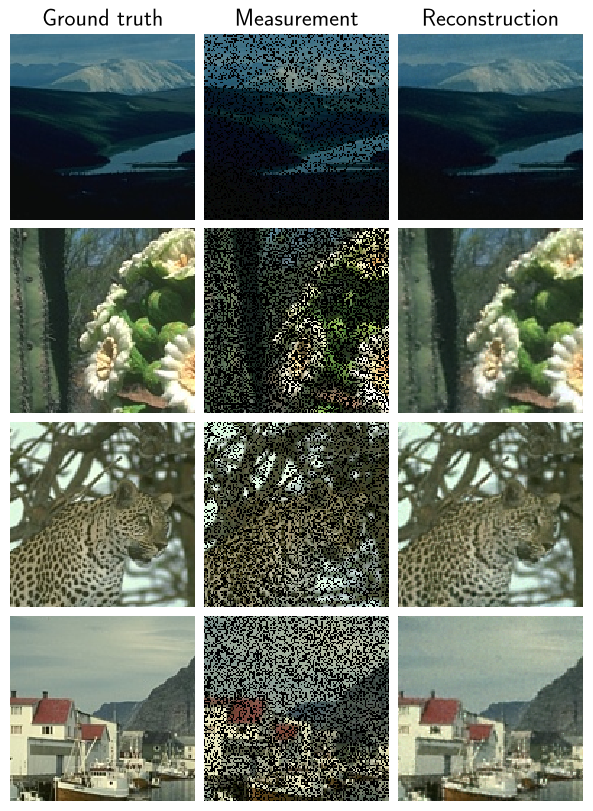

Eval epoch 3/5:   0%|          | 0/3 [00:00<?, ?it/s, PSNR=27.7]

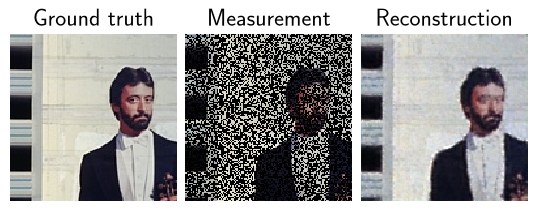

Eval epoch 3/5: 100%|██████████| 3/3 [00:01<00:00,  2.40it/s, PSNR=27.7]

Best model saved at epoch 3



Train epoch 4/5:  93%|█████████▎| 14/15 [00:03<00:00,  4.59it/s, TotalLoss=0.00192, PSNR=29.2]

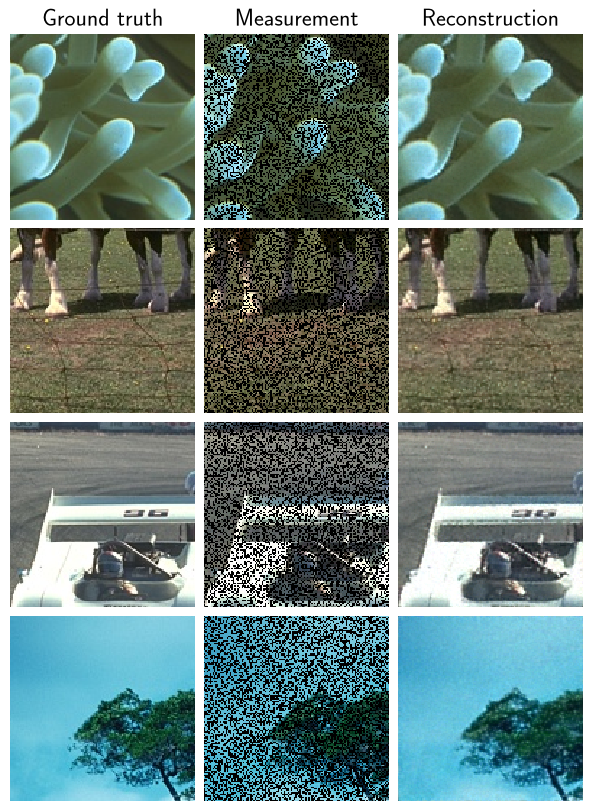

Eval epoch 4/5:   0%|          | 0/3 [00:00<?, ?it/s, PSNR=25.8]

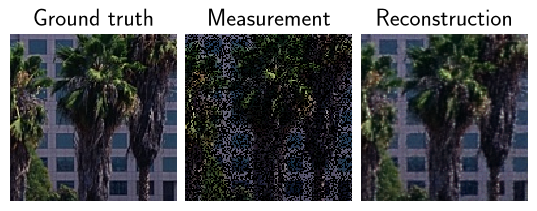

Train epoch 5/5:  93%|█████████▎| 14/15 [00:03<00:00,  4.46it/s, TotalLoss=0.00175, PSNR=29.5]

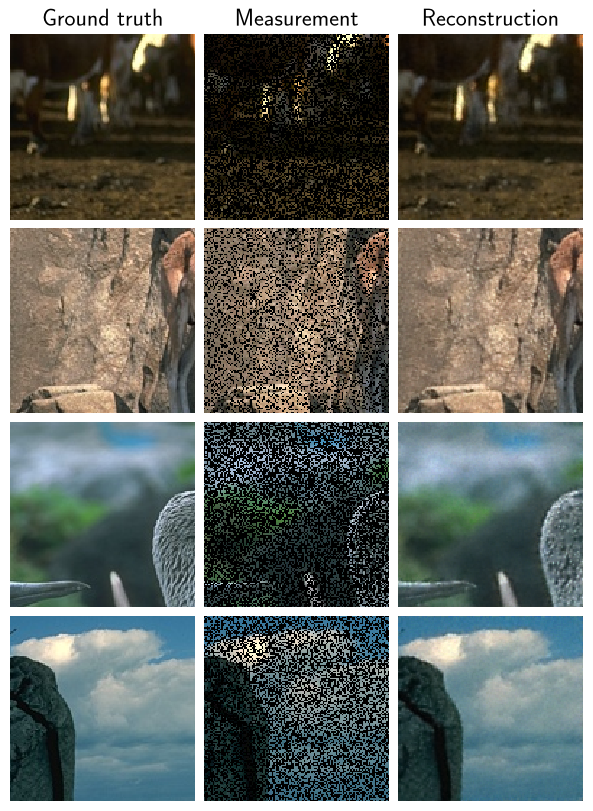

Eval epoch 5/5:  67%|██████▋   | 2/3 [00:00<00:00, 17.30it/s, PSNR=27]  

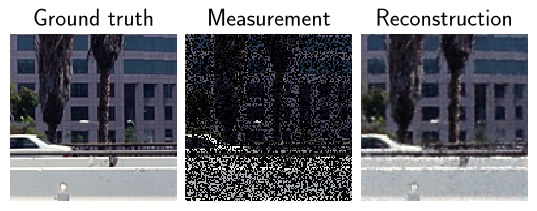

Eval epoch 5/5: 100%|██████████| 3/3 [00:00<00:00,  8.61it/s, PSNR=27]


In [ ]:
# define a Trainer, with online measurements, supervised learning, and PSNR metric


Test:   0%|          | 0/3 [00:00<?, ?it/s]

Test:  67%|██████▋   | 2/3 [00:00<00:00,  5.38it/s, PSNR=27.7, PSNR no learning=10.2]

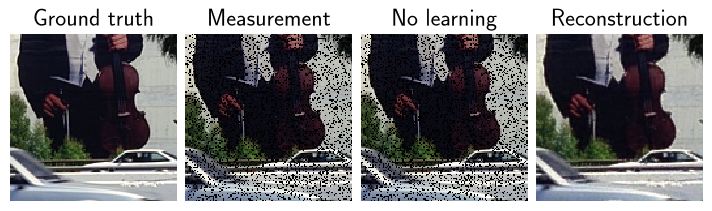

Test: 100%|██████████| 3/3 [00:00<00:00,  4.56it/s, PSNR=27.7, PSNR no learning=10.2]

Test results:
PSNR no learning: 10.176 +- 2.837
PSNR: 27.728 +- 5.999


{'PSNR no learning': 10.175660133361816,
 'PSNR no learning_std': 2.837211380179849,
 'PSNR': 27.727556228637695,
 'PSNR_std': 5.999416599119635,
 'runtime': 0.6625481949999994,
 'peak_gpu_memory_usage': 0.5320849418640137}

In [ ]:
# test learned model